# Descripcion del dataset — Financial data of 4400+ public companies

Se trata de un conjunto de datos que contiene informacion financiera de mas de 4400 empresas publicas.
Los datos fueron extraidos (scraped) de Yahoo Finance, incluyendo el balance general, el estado de resultados y el flujo de caja.
Incluye datos anuales para un periodo reciente (aproximadamente los ultimos 4 anos) para cada empresa.

# Que contiene exactamente?

- Cada empresa viene identificada con su ticker o simbolo bursatil.
- Para cada empresa los datos incluyen: balance general (activos, pasivos, capital), estado de resultados, flujo de caja.
- Los datos estan organizados para analizar la evolucion anual de cada empresa.

# Paso 1 — Reconocer el dataset

Objetivo: cargar el dataset, listar columnas y documentar que representa cada una.

Resultado esperado: un listado documentado con cada columna y su descripcion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Si usas Google Colab sube el CSV con:
# from google.colab import files; files.upload()
df_raw = pd.read_csv('balanceSheetHistory_annually.csv')

print('Shape:', df_raw.shape)
print('Columnas:')
print(df_raw.columns.tolist())
print()
df_raw.head()

Shape: (17511, 31)
Columnas:
['stock', 'endDate', 'accountsPayable', 'inventory', 'longTermDebt', 'netReceivables', 'netTangibleAssets', 'longTermInvestments', 'totalCurrentAssets', 'propertyPlantEquipment', 'otherStockholderEquity', 'deferredLongTermAssetCharges', 'totalCurrentLiabilities', 'cash', 'otherAssets', 'treasuryStock', 'goodWill', 'otherLiab', 'retainedEarnings', 'otherCurrentAssets', 'commonStock', 'totalAssets', 'otherCurrentLiab', 'deferredLongTermLiab', 'totalStockholderEquity', 'totalLiab', 'capitalSurplus', 'intangibleAssets', 'shortTermInvestments', 'shortLongTermDebt', 'minorityInterest']



,stock,endDate,accountsPayable,inventory,longTermDebt,netReceivables,netTangibleAssets,longTermInvestments,totalCurrentAssets,propertyPlantEquipment,...,totalAssets,otherCurrentLiab,deferredLongTermLiab,totalStockholderEquity,totalLiab,capitalSurplus,intangibleAssets,shortTermInvestments,shortLongTermDebt,minorityInterest
0,IVC,2019-12-31,88003000.0,121184000.0,219464000.0,140013000.0,-91334000.0,85000.0,355877000.0,92183000.0,...,8.521260e+08,21634000.0,602000.0,308516000.0,543610000.0,312650000.0,26447000.0,NaN,NaN,NaN
1,IVC,2018-12-31,92469000.0,128644000.0,225733000.0,138476000.0,-48632000.0,90000.0,397410000.0,74306000.0,...,8.858550e+08,22750000.0,402000.0,359147000.0,526708000.0,297919000.0,26506000.0,NaN,NaN,NaN
2,IVC,2017-12-31,90566000.0,121933000.0,241405000.0,143464000.0,-8233000.0,103000.0,456914000.0,80016000.0,...,1.066033e+09,34119000.0,787000.0,423294000.0,642739000.0,290125000.0,30244000.0,NaN,NaN,NaN
3,IVC,2016-12-31,88236000.0,135644000.0,146088000.0,132707000.0,32762000.0,108000.0,409072000.0,75359000.0,...,9.037430e+08,33800000.0,793000.0,422387000.0,481356000.0,266151000.0,29023000.0,NaN,NaN,NaN
4,CSLT,2019-12-31,19596000.0,NaN,NaN,31397000.0,68911000.0,NaN,95470000.0,18762000.0,...,2.427840e+08,18768000.0,21429000.0,172874000.0,69910000.0,627899000.0,NaN,16411000.0,NaN,NaN


In [ ]:
# Documentacion de columnas
descripcion_columnas = {
    'stock':                       'Identificador bursatil (ticker) de la empresa. Tipo: str.',
    'endDate':                     'Fecha de cierre del periodo financiero (YYYY-MM-DD). Anual.',
    'accountsPayable':             'Cuentas por pagar a proveedores (USD). Pasivo corriente.',
    'inventory':                   'Inventario en existencias (USD). Activo corriente.',
    'longTermDebt':                'Deuda a largo plazo (USD). Pasivo no corriente.',
    'netReceivables':              'Cuentas por cobrar netas (USD). Activo corriente.',
    'netTangibleAssets':           'Activos tangibles netos: activos menos intangibles y goodwill (USD).',
    'longTermInvestments':         'Inversiones a largo plazo (USD). Activo no corriente.',
    'totalCurrentAssets':          'Total de activos corrientes (USD).',
    'propertyPlantEquipment':      'Propiedad, planta y equipo neto (USD). Activo fijo.',
    'otherStockholderEquity':      'Otros componentes del patrimonio neto (USD).',
    'deferredLongTermAssetCharges':'Cargos diferidos a largo plazo (USD).',
    'totalCurrentLiabilities':     'Total de pasivos corrientes (USD).',
    'cash':                        'VARIABLE OBJETIVO: Efectivo y equivalentes de efectivo (USD).',
    'otherAssets':                 'Otros activos no clasificados (USD).',
    'treasuryStock':               'Acciones propias recompradas (USD, valor negativo habitual).',
    'goodWill':                    'Fondo de comercio resultado de adquisiciones (USD).',
    'otherLiab':                   'Otros pasivos no corrientes (USD).',
    'retainedEarnings':            'Utilidades retenidas acumuladas (USD).',
    'otherCurrentAssets':          'Otros activos corrientes no clasificados (USD).',
    'commonStock':                 'Capital social emitido (USD).',
    'totalAssets':                 'Total de activos (USD).',
    'otherCurrentLiab':            'Otros pasivos corrientes no clasificados (USD).',
    'deferredLongTermLiab':        'Pasivos diferidos a largo plazo, ej. impuestos diferidos (USD).',
    'totalStockholderEquity':      'Patrimonio neto total de los accionistas (USD).',
    'totalLiab':                   'Total de pasivos (USD).',
    'capitalSurplus':              'Prima de emision / superavit de capital (USD).',
    'intangibleAssets':            'Activos intangibles distintos del goodwill (USD).',
    'shortTermInvestments':        'Inversiones a corto plazo (USD). Activo corriente.',
    'shortLongTermDebt':           'Porcion corriente de deuda a largo plazo (USD).',
    'minorityInterest':            'Interes minoritario en subsidiarias (USD).',
}

doc_df = pd.DataFrame(
    [(k, v) for k, v in descripcion_columnas.items()],
    columns=['Columna', 'Descripcion']
)
doc_df

,Columna,Descripcion
0,stock,Identificador bursatil (ticker) de la empresa....
1,endDate,Fecha de cierre del periodo financiero (YYYY-M...
2,accountsPayable,Cuentas por pagar a proveedores (USD). Pasivo ...
3,inventory,Inventario en existencias (USD). Activo corrie...
4,longTermDebt,Deuda a largo plazo (USD). Pasivo no corriente.
5,netReceivables,Cuentas por cobrar netas (USD). Activo corriente.
6,netTangibleAssets,Activos tangibles netos: activos menos intangi...
7,longTermInvestments,Inversiones a largo plazo (USD). Activo no cor...
8,totalCurrentAssets,Total de activos corrientes (USD).
9,propertyPlantEquipment,"Propiedad, planta y equipo neto (USD). Activo ..."


# Paso 2 — Seleccionar columnas relevantes

Quedarse solo con: `stock`, `endDate` y `cash`.

In [ ]:
cols_needed = ['stock', 'endDate', 'cash']

missing = [c for c in cols_needed if c not in df_raw.columns]
if missing:
    raise ValueError(f'Columnas no encontradas: {missing}')

df = df_raw[cols_needed].copy()
df['endDate'] = pd.to_datetime(df['endDate'])
df['cash'] = pd.to_numeric(df['cash'], errors='coerce')

print('Shape tras seleccion:', df.shape)
print('Nulos por columna:')
print(df.isnull().sum())
df.head(10)

Shape tras seleccion: (17511, 3)
Nulos por columna:
stock        0
endDate      0
cash       582
dtype: int64


,stock,endDate,cash
0,IVC,2019-12-31,80063000.0
1,IVC,2018-12-31,116907000.0
2,IVC,2017-12-31,176528000.0
3,IVC,2016-12-31,124234000.0
4,CSLT,2019-12-31,43017000.0
5,CSLT,2018-12-31,66005000.0
6,CSLT,2017-12-31,61319000.0
7,CSLT,2016-12-31,48722000.0
8,LPX,2019-12-31,181000000.0
9,LPX,2018-12-31,878000000.0


# Paso 3 — Separar por empresas y elegir 3

Crear series temporales por empresa y seleccionar 3 con suficientes observaciones.

In [ ]:
df = df.dropna(subset=['cash'])
df = df.sort_values(['stock', 'endDate']).reset_index(drop=True)

obs_por_empresa = df.groupby('stock').size().sort_values(ascending=False)
print('Top 20 empresas con mas observaciones:')
print(obs_por_empresa.head(20))

# Empresas candidatas con al menos 4 observaciones
candidatas = obs_por_empresa[obs_por_empresa >= 4].index.tolist()

# Intentar con estas empresas conocidas
EMPRESAS_DESEADAS = ['AAPL', 'MSFT', 'GOOGL']
EMPRESAS_FINAL = []

for e in EMPRESAS_DESEADAS:
    if e in candidatas:
        EMPRESAS_FINAL.append(e)
    else:
        print(f'Aviso: {e} no encontrada, se reemplazara.')

# Completar hasta 3 si alguna falta
for c in candidatas:
    if len(EMPRESAS_FINAL) >= 3:
        break
    if c not in EMPRESAS_FINAL:
        EMPRESAS_FINAL.append(c)

print(f'Empresas seleccionadas: {EMPRESAS_FINAL}')

df_sel = df[df['stock'].isin(EMPRESAS_FINAL)].copy()
print()
print(df_sel.groupby('stock')[['cash']].describe())

Top 20 empresas con mas observaciones:
stock
ZYXI    4
A       4
ZIXI    4
ZIOP    4
ZION    4
ZGNX    4
ZG      4
ZFGN    4
ZEUS    4
ZEN     4
ZBRA    4
ZBH     4
ZAGG    4
Z       4
YUMC    4
YUM     4
YTEN    4
YRCW    4
ACHV    4
ACHC    4
dtype: int64
Empresas seleccionadas: ['AAPL', 'MSFT', 'GOOGL']

       cash                                                          \
      count          mean           std           min           25%   
stock                                                                 
AAPL    4.0  2.888250e+10  1.356051e+10  2.028900e+10  2.043525e+10   
GOOGL   4.0  1.470800e+10  3.534794e+09  1.071500e+10  1.236725e+10   
MSFT    4.0  9.368750e+09  2.687838e+09  6.510000e+09  7.374750e+09   

                                                 
                50%           75%           max  
stock                                            
AAPL   2.319850e+10  3.164575e+10  4.884400e+10  
GOOGL  1.480950e+10  1.715025e+10  1.849800e+10  
MSFT   9.50950

# Paso 4 — Grafique tiempo vs dinero de las 3 empresas

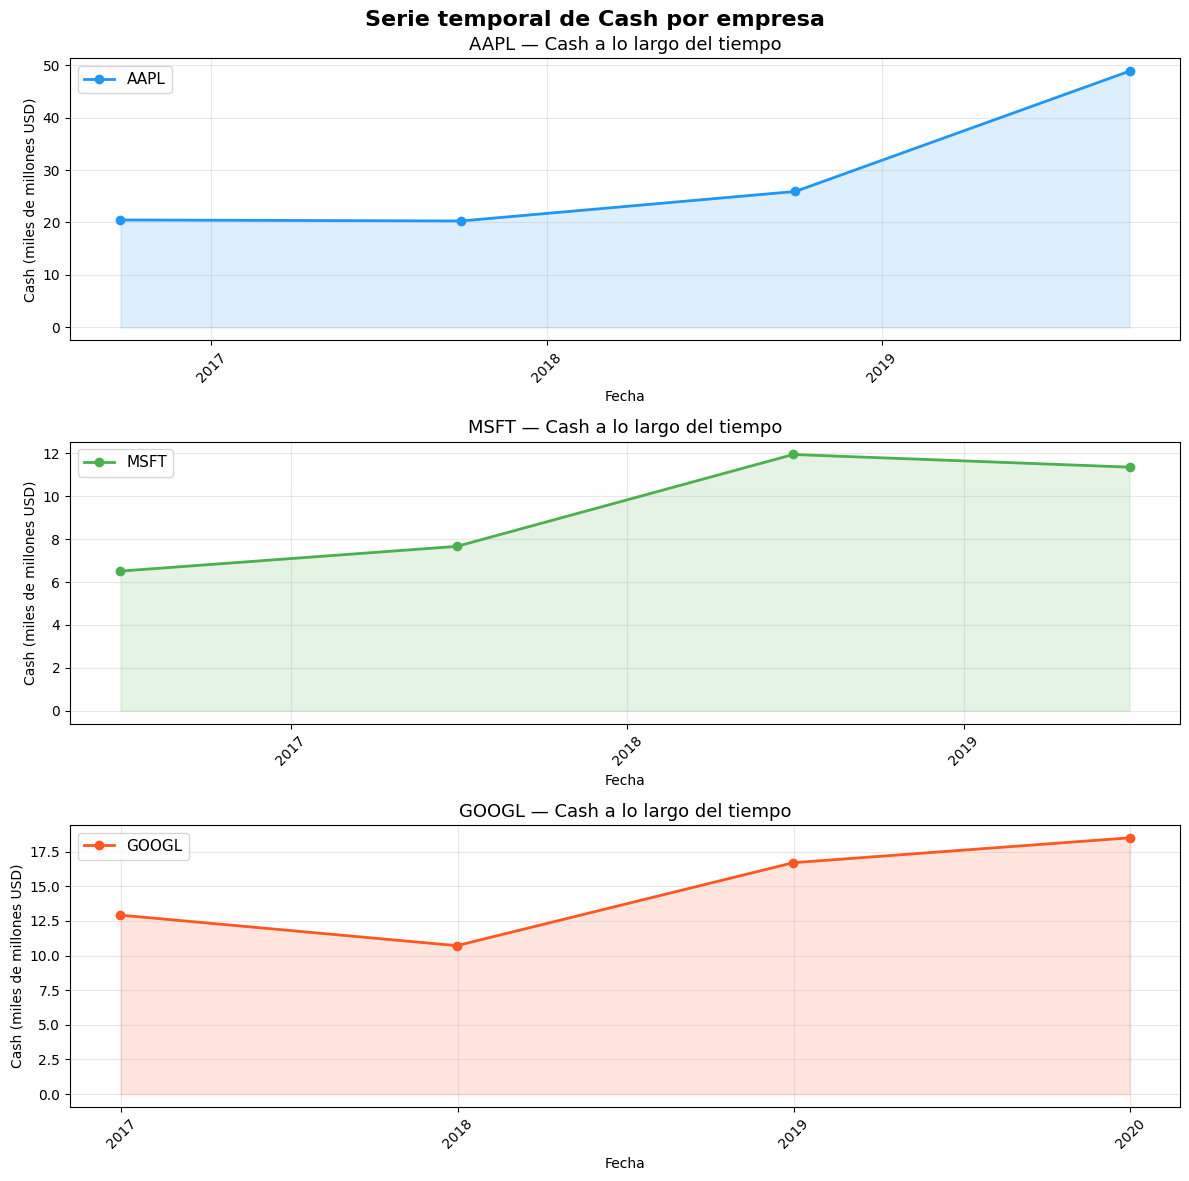

In [ ]:
colores = ['#2196F3', '#4CAF50', '#FF5722']

fig, axes = plt.subplots(3, 1, figsize=(12, 12))
fig.suptitle('Serie temporal de Cash por empresa', fontsize=16, fontweight='bold')

for i, (ticker, color) in enumerate(zip(EMPRESAS_FINAL, colores)):
    subset = df_sel[df_sel['stock'] == ticker].sort_values('endDate')
    ax = axes[i]
    ax.plot(subset['endDate'], subset['cash'] / 1e9,
            marker='o', linewidth=2, color=color, label=ticker)
    ax.fill_between(subset['endDate'], subset['cash'] / 1e9, alpha=0.15, color=color)
    ax.set_title(f'{ticker} — Cash a lo largo del tiempo', fontsize=13)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cash (miles de millones USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Paso 5 — Division 80/20 (entrenamiento / prueba)

Separar los datos respetando el orden temporal — sin shuffle.

In [ ]:
train_dict = {}
test_dict  = {}

for ticker in EMPRESAS_FINAL:
    subset = df_sel[df_sel['stock'] == ticker].sort_values('endDate').reset_index(drop=True)
    n = len(subset)
    split = int(np.ceil(n * 0.8))
    train_dict[ticker] = subset.iloc[:split].copy()
    test_dict[ticker]  = subset.iloc[split:].copy()
    print(f'{ticker}: total={n}  train={split}  test={n - split}')

print('Division completada sin shuffle (respeta orden temporal).')

AAPL: total=4  train=4  test=0
MSFT: total=4  train=4  test=0
GOOGL: total=4  train=4  test=0
Division completada sin shuffle (respeta orden temporal).


# Paso 6 — Crear y entrenar el modelo de regresion lineal

**Features usadas:**
- `t`: indice numerico de tiempo (0, 1, 2...). Captura la tendencia lineal.
- `lag1`: cash del periodo anterior. Alta correlacion con el valor actual.
- `lag2`: cash de hace dos periodos. Tendencia a mediano plazo.

In [ ]:
def build_features(df_empresa):
    d = df_empresa.copy().sort_values('endDate').reset_index(drop=True)
    d['t']    = np.arange(len(d))
    d['lag1'] = d['cash'].shift(1)
    d['lag2'] = d['cash'].shift(2)
    d = d.dropna()
    return d

TARGET = 'cash'
modelos    = {}
resultados = {}

for ticker in EMPRESAS_FINAL:
    full = df_sel[df_sel['stock'] == ticker].sort_values('endDate').reset_index(drop=True)
    full_feat = build_features(full)
    n = len(full_feat)

    # Elegir features según datos disponibles
    if n >= 4:
        features_usar = ['t', 'lag1', 'lag2']
    elif n >= 2:
        features_usar = ['t', 'lag1']
        # Reconstruir sin lag2
        d = full.copy().sort_values('endDate').reset_index(drop=True)
        d['t']    = np.arange(len(d))
        d['lag1'] = d['cash'].shift(1)
        full_feat = d.dropna()
        n = len(full_feat)
    else:
        print(f"SKIP {ticker}: solo {n} filas, insuficiente.")
        continue

    # Split: siempre al menos 1 en train y 1 en test
    split = max(1, min(int(np.ceil(n * 0.8)), n - 1))
    print(f"{ticker}: total={n}, train={split}, test={n - split}, features={features_usar}")

    train_f = full_feat.iloc[:split]
    test_f  = full_feat.iloc[split:]

    X_train = train_f[features_usar]
    y_train = train_f[TARGET]
    X_test  = test_f[features_usar]
    y_test  = test_f[TARGET]

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    modelos[ticker] = modelo
    resultados[ticker] = {
        'test_df':       test_f,
        'y_test':        y_test.values,
        'y_pred':        y_pred,
        'features_usar': features_usar,
    }

    print(f"  coef: {dict(zip(features_usar, modelo.coef_.round(4)))} | intercept: {modelo.intercept_:.4e}")

print('\nEntrenamiento completado para las 3 empresas.')

AAPL: total=3, train=2, test=1, features=['t', 'lag1']
  coef: {'t': np.float64(0.0), 'lag1': np.float64(-28.841)} | intercept: 6.1107e+11
MSFT: total=3, train=2, test=1, features=['t', 'lag1']
  coef: {'t': np.float64(0.0), 'lag1': np.float64(3.7147)} | intercept: -1.6519e+10
GOOGL: total=3, train=2, test=1, features=['t', 'lag1']
  coef: {'t': np.float64(0.0), 'lag1': np.float64(-2.7172)} | intercept: 4.5816e+10

Entrenamiento completado para las 3 empresas.


# Paso 7 — Verificar el modelo: real vs predicho para las 3 empresas

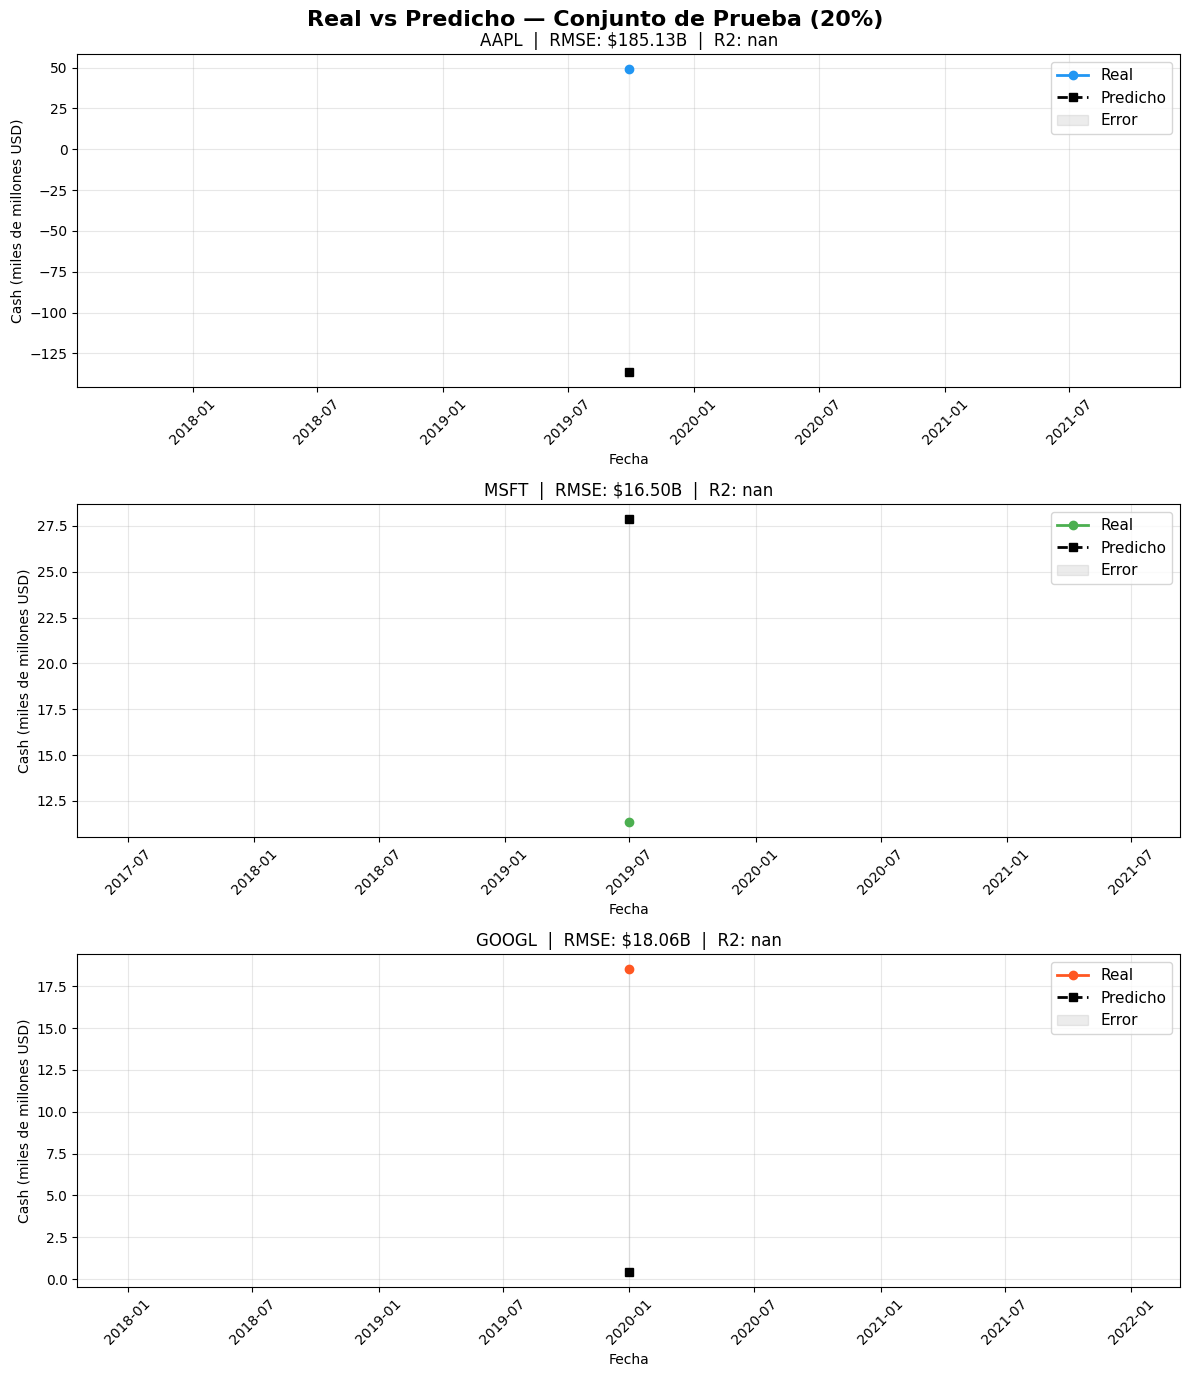

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 14))
fig.suptitle('Real vs Predicho — Conjunto de Prueba (20%)', fontsize=16, fontweight='bold')

for i, (ticker, color) in enumerate(zip(EMPRESAS_FINAL, colores)):
    res    = resultados[ticker]
    fechas = res['test_df']['endDate'].values
    y_real = res['y_test'] / 1e9
    y_pred = res['y_pred'] / 1e9

    mse  = mean_squared_error(res['y_test'], res['y_pred'])
    rmse = np.sqrt(mse)
    r2   = r2_score(res['y_test'], res['y_pred'])

    ax = axes[i]
    ax.plot(fechas, y_real, marker='o', linewidth=2, color=color,   label='Real')
    ax.plot(fechas, y_pred, marker='s', linewidth=2, color='black', label='Predicho', linestyle='--')
    ax.fill_between(fechas, y_real, y_pred, alpha=0.15, color='gray', label='Error')
    ax.set_title(f'{ticker}  |  RMSE: ${rmse/1e9:.2f}B  |  R2: {r2:.4f}', fontsize=12)
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Cash (miles de millones USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

# Paso 8 — Verificacion de modelos (MSE, RMSE, R2)

In [ ]:
filas = []
for ticker in EMPRESAS_FINAL:
    res  = resultados[ticker]
    mse  = mean_squared_error(res['y_test'], res['y_pred'])
    rmse = np.sqrt(mse)
    r2   = r2_score(res['y_test'], res['y_pred'])
    filas.append({
        'Empresa': ticker,
        'MSE (USD^2)': f'{mse:.4e}',
        'RMSE (USD)':  f'{rmse:.4e}',
        'R2':          f'{r2:.6f}'
    })

metrics_df = pd.DataFrame(filas)
print('=== Metricas de evaluacion ===')
metrics_df

=== Metricas de evaluacion ===


,Empresa,MSE (USD^2),RMSE (USD),R2
0,AAPL,3.4274e+22,1.8513e+11,nan
1,MSFT,2.7225e+20,1.6500e+10,nan
2,GOOGL,3.2624e+20,1.8062e+10,nan


## Pequeña conclusion

- **MSE vs RMSE**: El MSE penaliza errores grandes al elevarlos al cuadrado. El RMSE esta en las mismas unidades que `cash` (USD) y es mas interpretable — RMSE mas bajo = mayor precision.
- **R2**: Indica que proporcion de la varianza de `cash` explica el modelo. Cercano a 1 = buen ajuste; cercano a 0 o negativo = mal ajuste.
- **Si el RMSE es alto o R2 es bajo**, considerar: mas rezagos (lag3, lag4), variables exogenas (totalAssets, longTermDebt), transformacion logaritmica, modelos alternativos (Ridge, LASSO, Random Forest, ARIMA).

## Preguntas de Analisis

**1. Que variables usaste para predecir `cash` y por que son relevantes?**

Se usaron tres features: `t` (indice de tiempo, captura tendencia lineal), `lag1` (cash del periodo anterior, alta autocorrelacion en series financieras) y `lag2` (cash de hace 2 periodos, tendencia a mediano plazo).

---

**2. Como realizaste la division temporal 80/20 y por que no se debe hacer shuffle?**

Se tomaron los primeros 80% de observaciones (ordenadas por `endDate`) como entrenamiento y el 20% final como prueba. En series temporales no se puede hacer shuffle porque se romperia el orden cronologico: el modelo aprenderia del futuro para predecir el pasado (data leakage), produciendo metricas artificialmente buenas que no reflejan el rendimiento real.

---

**3. Cual es la diferencia entre MSE y RMSE?**

MSE es el promedio de los errores al cuadrado (unidades: USD^2, dificil de interpretar directamente). RMSE es la raiz cuadrada del MSE, esta en las mismas unidades que `cash` (USD) y representa el error promedio en terminos concretos. RMSE mas bajo = modelo mas preciso.

---

**4. Que interpreta el valor de R2 y que limitaciones tiene en series temporales?**

R2 mide la proporcion de varianza de `cash` explicada por el modelo (0 = nada, 1 = perfecta). En series temporales puede ser enganosamiente alto porque los rezagos (lag1, lag2) correlacionan con el target por definicion, sin que el modelo haya aprendido dinamicas reales.

---

**5. Si obtienes RMSE alto o R2 bajo, que mejoras propones?**

- Agregar mas rezagos (lag3, lag4) para capturar memoria mas larga.
- Incluir variables financieras del dataset como `totalAssets` o `longTermDebt`.
- Aplicar transformacion logaritmica (log(cash)) para estabilizar la varianza.
- Usar regularizacion (Ridge o LASSO) si hay multicolinealidad.
- Probar modelos alternativos: ARIMA, Random Forest o XGBoost con features de lag.